1. **Overall NHT type effect (Kruskal-Wallis):**

  * No significant difference across *specific NHT agents alone* (p = 0.545).
  * Interpretation: NHT type by itself does not explain time differences well.

2. **ADT agent effect (Kruskal-Wallis):**

  * Strongly significant (p = 0.00020).
  * Interpretation: ADT backbone therapy is a major driver of time variation.

3. **ADT × NHT interaction structure (Kruskal-Wallis across pairs):**

  * Significant overall effect (p = 0.00016).
  * Interpretation: The combination of ADT + NHT matters more than either alone.

4. **Pairwise comparisons (key pattern):**

  * Most comparisons = not significant after correction (many p = 1.0), suggesting sparse separation overall.
  * Some notable lower p-values:

    * Lupron → Darolutamide shows strongest evidence of difference vs several groups
    * Orgovyx → Darolutamide also shows some moderate evidence of differences in certain comparisons.
  * Overall: effects appear driven by a few specific combinations rather than widespread separation.

5. **Median/central tendency pattern (descriptive trend):**

  * Lower medians:

    * Orgovyx + Darolutamide (very low median ~15 days in one subgroup)
    * Orgovyx + Abiraterone (~29.5 days)
    * Firmagon + Abiraterone (~32.5–35.5 days)
  * Higher medians:

    * Lupron + Enzalutamide (~785 days)
    * Lupron + Darolutamide (~883 days)
    * Orgovyx + Darolutamide shows high variability with extreme outliers in some groups (up to ~1370+ days)
  * Interpretation: strong heterogeneity and skewed distributions across combinations.

6. **OLS regression (log_time model):**

  * Model is significant overall (F-test p ≈ 1.8e-05).
  * Moderate explanatory power (R² ≈ 0.24).
  * Key findings:

    * No single ADT or NHT main effect is strongly significant at 0.05 level.
    * Orgovyx shows a borderline negative association (p ≈ 0.094).
  * Interpretation: regression suggests weak-to-moderate global signal but no dominant independent predictors after adjustment.

7. **Overall interpretation across methods:**

  * NHT alone: not significant.
  * ADT backbone: strongly significant driver.
  * Interaction (ADT × NHT): important globally but driven by a small subset of combinations.
  * Data likely:

    * Highly imbalanced (many groups with n = 1–3)
    * Strongly right-skewed (long tail / extreme values)
    * Sensitive to small-sample noise in pairwise tests

Raw shape: (239, 60)
Clean shape: (164, 61)
count     164.000000
mean      322.408537
std       606.573043
min         0.000000
25%        16.000000
50%        48.000000
75%       280.750000
max      2883.000000
Name: time_to_nht, dtype: float64

NHT Summary:
                   count        mean  median         std
specific_nht_used                                       
Abiraterone           81  193.259259    43.0  445.151738
Apalutamide           11  250.818182    47.0  494.457646
Darolutamide          56  450.964286    54.0  708.625660
Enzalutamide          16  575.500000   148.0  844.550373

ADT Summary:
              count        mean  median         std
adt_agent                                          
Orgovyx          68  141.073529    25.0  284.813126
Firmagon         19   65.789474    38.0  100.049198
Bicalutamide     24  220.250000    67.5  504.272291
Lupron           53  693.320755   259.0  848.978114


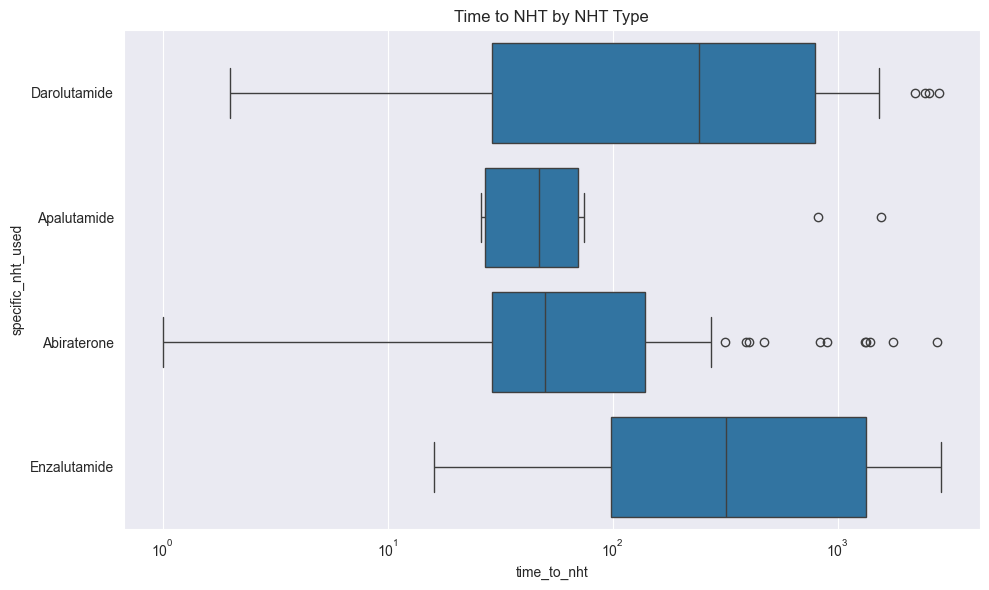

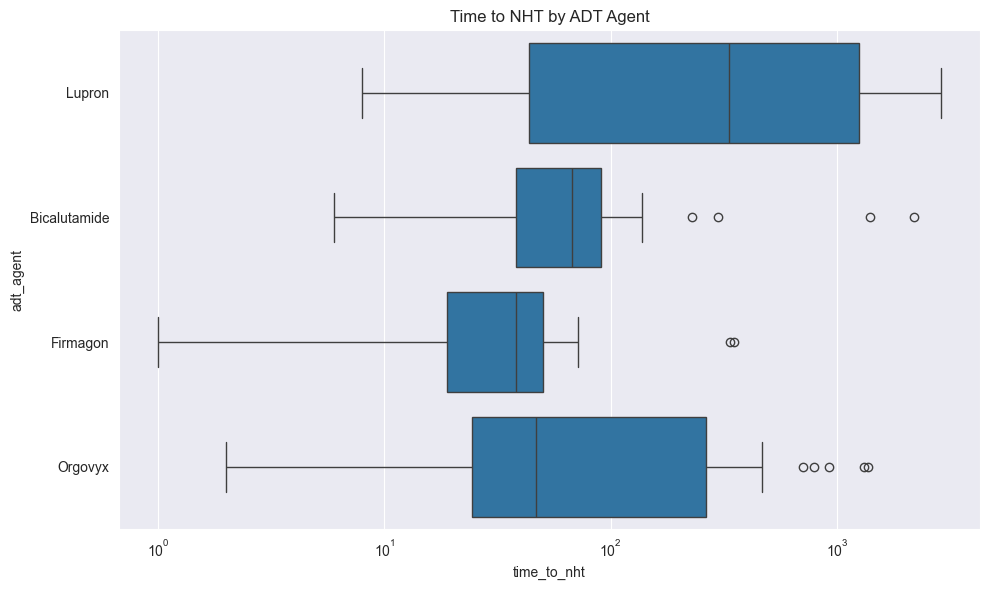

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


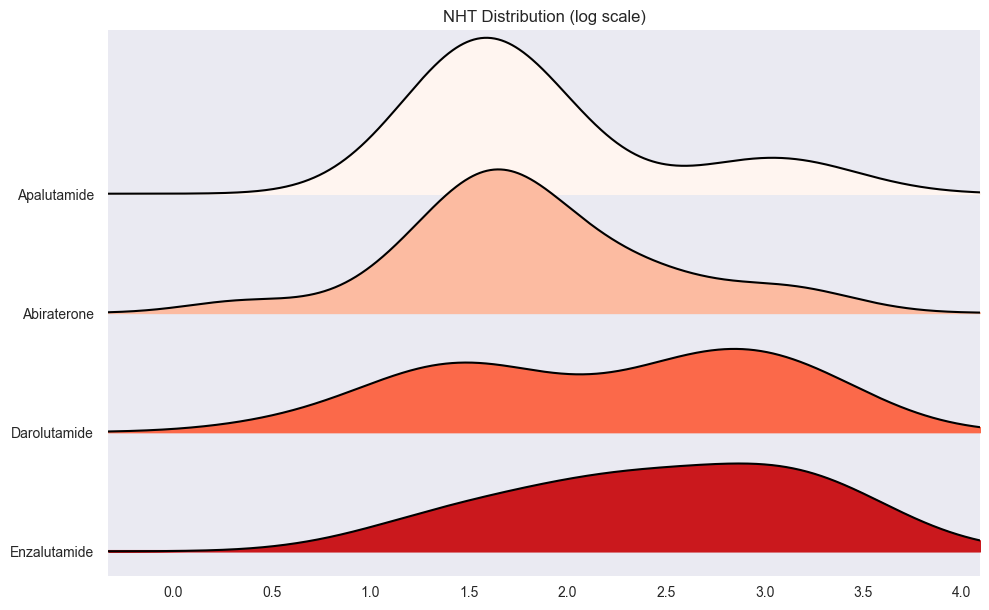

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


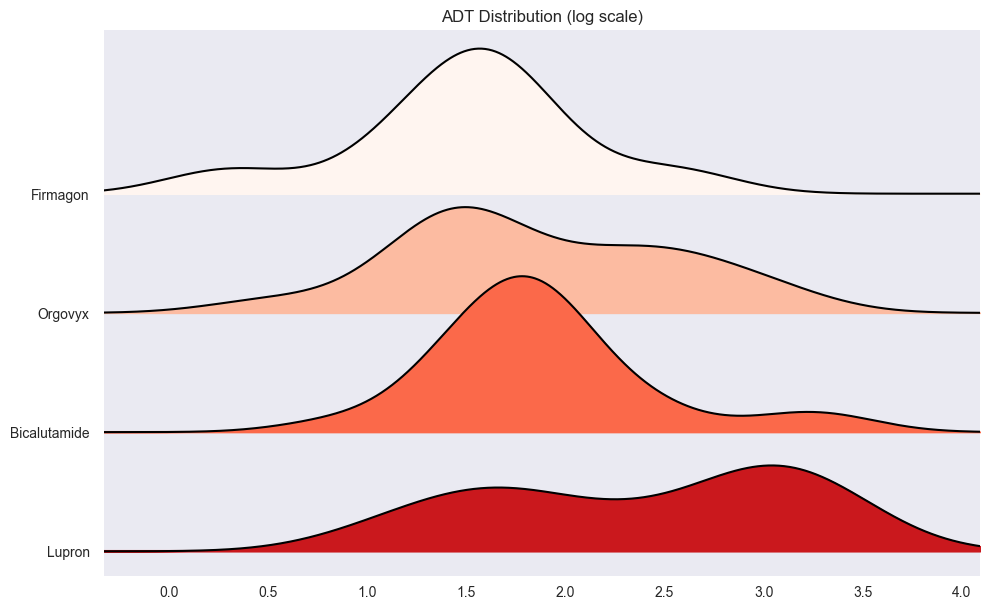

Kruskal-Wallis (specific_nht_used): p = 0.54545
Kruskal-Wallis (adt_agent): p = 0.00000
       adt_agent specific_nht_used  count  median         mean          std
13       Orgovyx      Darolutamide     29    16.0   178.482759   344.236798
12       Orgovyx       Apalutamide      3    28.0    29.000000     3.605551
11       Orgovyx       Abiraterone     28    29.5    81.178571   124.176414
5       Firmagon       Apalutamide      2    36.5    36.500000    14.849242
4       Firmagon       Abiraterone     13    38.0    35.538462    22.269618
14       Orgovyx      Enzalutamide      8    52.5   257.125000   449.468396
0   Bicalutamide       Abiraterone     13    57.0   169.846154   374.149223
1   Bicalutamide       Apalutamide      3    66.0    55.666667    26.083200
7         Lupron       Abiraterone     27    69.0   396.703704   677.974859
2   Bicalutamide      Darolutamide      7    77.0   400.571429   797.155747
3   Bicalutamide      Enzalutamide      1   107.0   107.000000          NaN


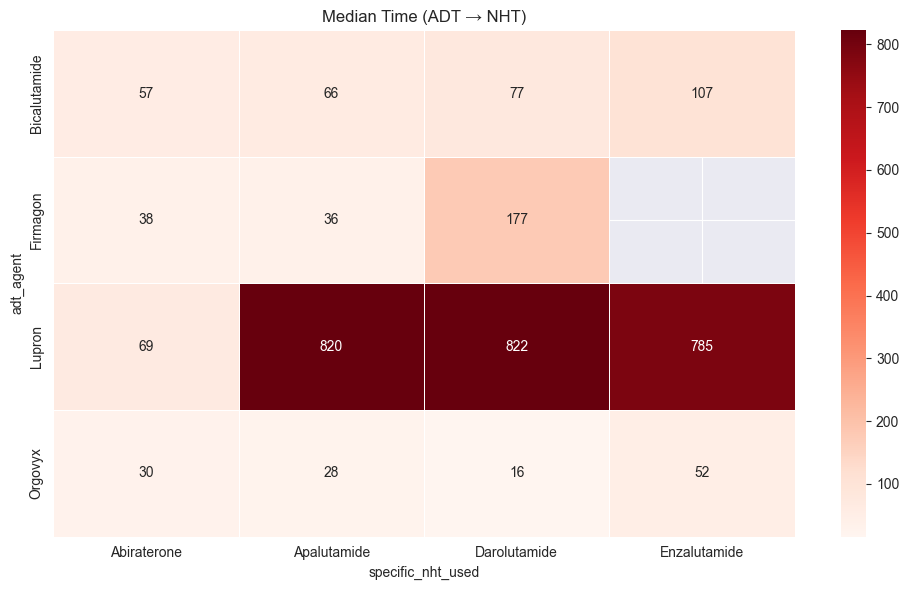

Kruskal (ADT × NHT pairs): p = 0.00007
                             Bicalutamide → Abiraterone  \
Bicalutamide → Abiraterone                     1.000000   
Bicalutamide → Darolutamide                    1.000000   
Firmagon → Abiraterone                         1.000000   
Lupron → Abiraterone                           1.000000   
Lupron → Darolutamide                          0.653756   
Lupron → Enzalutamide                          1.000000   
Orgovyx → Abiraterone                          1.000000   
Orgovyx → Darolutamide                         1.000000   
Orgovyx → Enzalutamide                         1.000000   

                             Bicalutamide → Darolutamide  \
Bicalutamide → Abiraterone                      1.000000   
Bicalutamide → Darolutamide                     1.000000   
Firmagon → Abiraterone                          1.000000   
Lupron → Abiraterone                            1.000000   
Lupron → Darolutamide                           1.000000   
Lupron → E

In [10]:
# =============================
# TIME-TO-NHT ANALYSIS PIPELINE
# =============================

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
import scikit_posthocs as sp
import joypy

# -----------------------------
# Paths & Load
# -----------------------------
BASE_FILE = os.path.join(
    "..", "..", "data", "processed",
    "cardio_onc_prostate_06_broad_clean.csv"
)

df = pd.read_csv(BASE_FILE)
print("Raw shape:", df.shape)

# -----------------------------
# Preprocessing
# -----------------------------
def prepare_time_variable(df):
    df = df.copy()
    df["nht_start_date"] = pd.to_datetime(df["nht_start_date"], errors="coerce")
    df["adt_start_date"] = pd.to_datetime(df["adt_start_date"], errors="coerce")

    df["time_to_nht"] = (
        df["nht_start_date"] - df["adt_start_date"]
    ).dt.days

    return df


def clean_data(df):
    df = df.copy()

    df = df[
        (df["time_to_nht"].notna()) &
        (df["time_to_nht"] >= 0) &
        (df["specific_nht_used"].notna()) &
        (df["adt_agent"].notna())
    ]

    # Cap extreme outliers (99th percentile)
    upper = df["time_to_nht"].quantile(0.99)
    df = df[df["time_to_nht"] <= upper]

    return df


df = prepare_time_variable(df)
df_clean = clean_data(df)

print("Clean shape:", df_clean.shape)
print(df_clean["time_to_nht"].describe())

# -----------------------------
# Summaries
# -----------------------------
def summarize_by_group(df, group_var):
    return (
        df.groupby(group_var)["time_to_nht"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median")
    )


print("\nNHT Summary:")
print(summarize_by_group(df_clean, "specific_nht_used"))

print("\nADT Summary:")
print(summarize_by_group(df_clean, "adt_agent"))

# -----------------------------
# Visualization
# -----------------------------
def plot_boxplots(df):
    df_plot = df[df["time_to_nht"] > 0]

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot, y="specific_nht_used", x="time_to_nht")
    plt.xscale("log")
    plt.title("Time to NHT by NHT Type")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot, y="adt_agent", x="time_to_nht")
    plt.xscale("log")
    plt.title("Time to NHT by ADT Agent")
    plt.tight_layout()
    plt.show()


def plot_ridgelines(df):
    df_plot = df[df["time_to_nht"] > 0].copy()
    df_plot["log_time"] = np.log10(df_plot["time_to_nht"] + 1)

    # Order by median
    order_nht = (
        df_plot.groupby("specific_nht_used")["time_to_nht"]
        .median().sort_values().index
    )

    df_plot["specific_nht_used"] = pd.Categorical(
        df_plot["specific_nht_used"], categories=order_nht, ordered=True
    )

    joypy.joyplot(
        df_plot,
        by="specific_nht_used",
        column="log_time",
        figsize=(10, 6),
        colormap=plt.cm.Reds
    )
    plt.title("NHT Distribution (log scale)")
    plt.show()

    order_adt = (
        df_plot.groupby("adt_agent")["time_to_nht"]
        .median().sort_values().index
    )

    df_plot["adt_agent"] = pd.Categorical(
        df_plot["adt_agent"], categories=order_adt, ordered=True
    )

    joypy.joyplot(
        df_plot,
        by="adt_agent",
        column="log_time",
        figsize=(10, 6),
        colormap=plt.cm.Reds
    )
    plt.title("ADT Distribution (log scale)")
    plt.show()


plot_boxplots(df_clean)
plot_ridgelines(df_clean)

# -----------------------------
# Statistical Tests
# -----------------------------
def kruskal_test(df, group_var):
    groups = [
        g["time_to_nht"].values
        for _, g in df.groupby(group_var)
    ]
    _, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis ({group_var}): p = {p:.5f}")


kruskal_test(df_clean, "specific_nht_used")
kruskal_test(df_clean, "adt_agent")

# -----------------------------
# ADT × NHT Interaction
# -----------------------------
def compute_pair_summary(df):
    return (
        df.groupby(["adt_agent", "specific_nht_used"])["time_to_nht"]
        .agg(["count", "median", "mean", "std"])
        .reset_index()
    )


pair_summary = compute_pair_summary(df_clean)
print(pair_summary.sort_values("median"))

def plot_heatmap(pair_summary):
    heatmap_data = pair_summary.pivot(
        index="adt_agent",
        columns="specific_nht_used",
        values="median"
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        cmap="Reds",
        annot=True,
        fmt=".0f",
        linewidths=0.5
    )
    plt.title("Median Time (ADT → NHT)")
    plt.tight_layout()
    plt.show()


plot_heatmap(pair_summary)

# -----------------------------
# Pair Filtering + Global Test
# -----------------------------
def filter_valid_pairs(df, pair_summary, min_n=5):
    valid_pairs = pair_summary[pair_summary["count"] >= min_n]

    return df.merge(
        valid_pairs[["adt_agent", "specific_nht_used"]],
        on=["adt_agent", "specific_nht_used"],
        how="inner"
    )


df_valid = filter_valid_pairs(df_clean, pair_summary)

df_valid["adt_nht_pair"] = (
    df_valid["adt_agent"] + " → " + df_valid["specific_nht_used"]
)

groups = [
    g["time_to_nht"].values
    for _, g in df_valid.groupby("adt_nht_pair")
]

_, p = stats.kruskal(*groups)
print(f"Kruskal (ADT × NHT pairs): p = {p:.5f}")

# -----------------------------
# Post-hoc (Dunn)
# -----------------------------
posthoc = sp.posthoc_dunn(
    df_valid,
    val_col="time_to_nht",
    group_col="adt_nht_pair",
    p_adjust="bonferroni"
)

print(posthoc)

# -----------------------------
# Regression Model
# -----------------------------
df_valid["log_time"] = np.log1p(df_valid["time_to_nht"])

model = smf.ols(
    "log_time ~ C(adt_agent) * C(specific_nht_used)",
    data=df_valid
).fit()

print(model.summary())

# -----------------------------
# DONE
# -----------------------------
print("\nANALYSIS COMPLETE")

In [1]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as sp


BASE_FILE = os.path.join(
    "..", "..", "data", "processed",
    "cardio_onc_prostate_06_broad_clean.csv"
)

df = pd.read_csv(BASE_FILE)
print("Raw shape:", df.shape)

Raw shape: (239, 60)


In [2]:
def prepare_time_variable(df):
    df = df.copy()

    df["nht_start_date"] = pd.to_datetime(df["nht_start_date"], errors = "coerce")
    df["adt_start_date"] = pd.to_datetime(df["adt_start_date"], errors = "coerce")

    df["time_to_nht"] = (
            df["nht_start_date"] - df["adt_start_date"]
    ).dt.days

    return df


df = prepare_time_variable(df)

print(df["time_to_nht"].describe())


def clean_data(df):
    df_clean = df.copy()

    df_clean = df_clean[
        (df_clean["time_to_nht"].notna()) &
        (df_clean["time_to_nht"] >= 0) &
        (df_clean["specific_nht_used"].notna()) &
        (df_clean["adt_agent"].notna())
        ]

    # Remove extreme outliers (99th percentile)
    upper_cap = df_clean["time_to_nht"].quantile(0.99)
    df_clean = df_clean[df_clean["time_to_nht"] <= upper_cap]

    return df_clean


df_clean = clean_data(df)
print("Clean shape:", df_clean.shape)


def summarize_by_group(df, group_var):
    return (
        df.groupby(group_var)["time_to_nht"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("median")
    )


print("\nNHT Summary:")
print(summarize_by_group(df_clean, "specific_nht_used"))

print("\nADT Summary:")
print(summarize_by_group(df_clean, "adt_agent"))

count      193.000000
mean       514.414508
std       3137.188715
min       -731.000000
25%          0.000000
50%         36.000000
75%        189.000000
max      42761.000000
Name: time_to_nht, dtype: float64
Clean shape: (164, 61)

NHT Summary:
                   count        mean  median         std
specific_nht_used                                       
Abiraterone           81  193.259259    43.0  445.151738
Apalutamide           11  250.818182    47.0  494.457646
Darolutamide          56  450.964286    54.0  708.625660
Enzalutamide          16  575.500000   148.0  844.550373

ADT Summary:
              count        mean  median         std
adt_agent                                          
Orgovyx          68  141.073529    25.0  284.813126
Firmagon         19   65.789474    38.0  100.049198
Bicalutamide     24  220.250000    67.5  504.272291
Lupron           53  693.320755   259.0  848.978114


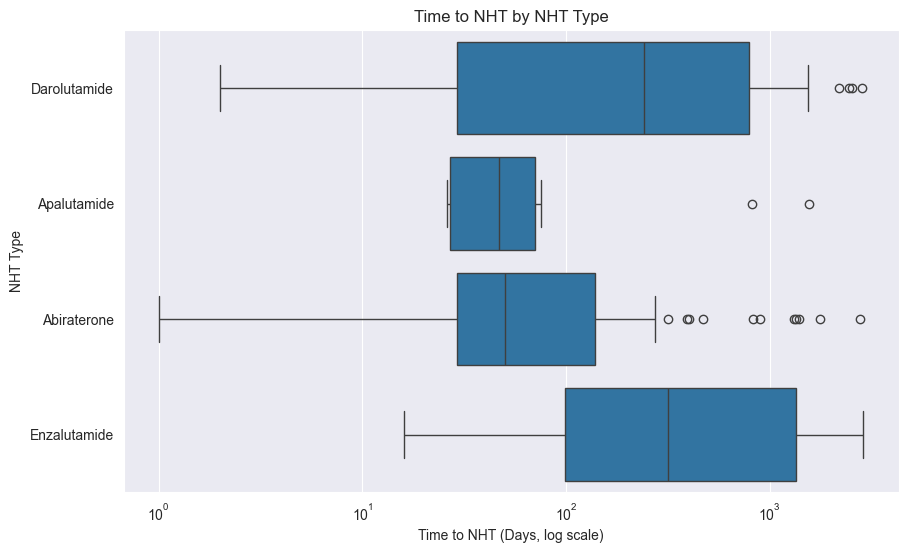

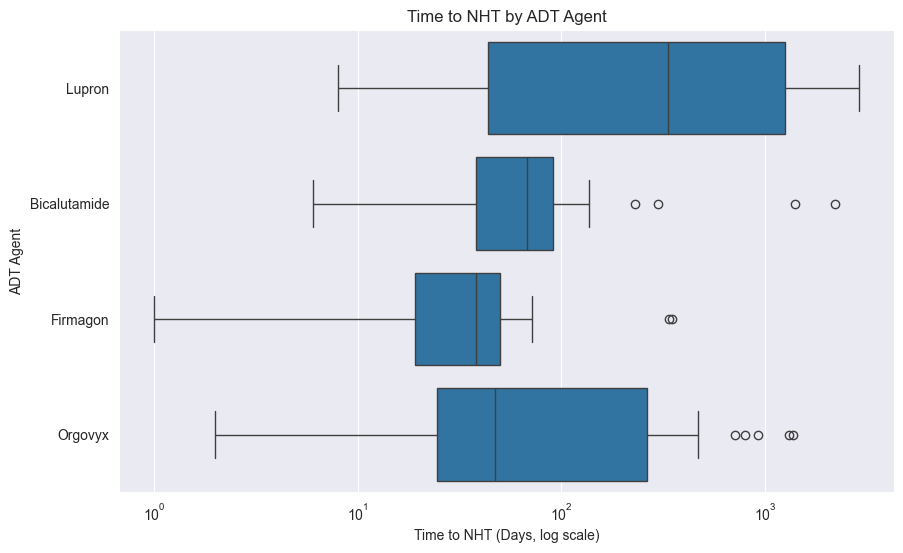

In [3]:
def plot_boxplots(df):
    df_plot = df[df["time_to_nht"] > 0]

    # NHT plot (horizontal)
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df_plot, y="specific_nht_used", x="time_to_nht")
    plt.xscale("log")
    plt.title("Time to NHT by NHT Type")
    plt.ylabel("NHT Type")
    plt.xlabel("Time to NHT (Days, log scale)")
    plt.show()

    # ADT plot (horizontal)
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df_plot, y="adt_agent", x="time_to_nht")
    plt.xscale("log")
    plt.title("Time to NHT by ADT Agent")
    plt.ylabel("ADT Agent")
    plt.xlabel("Time to NHT (Days, log scale)")
    plt.show()


plot_boxplots(df_clean)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


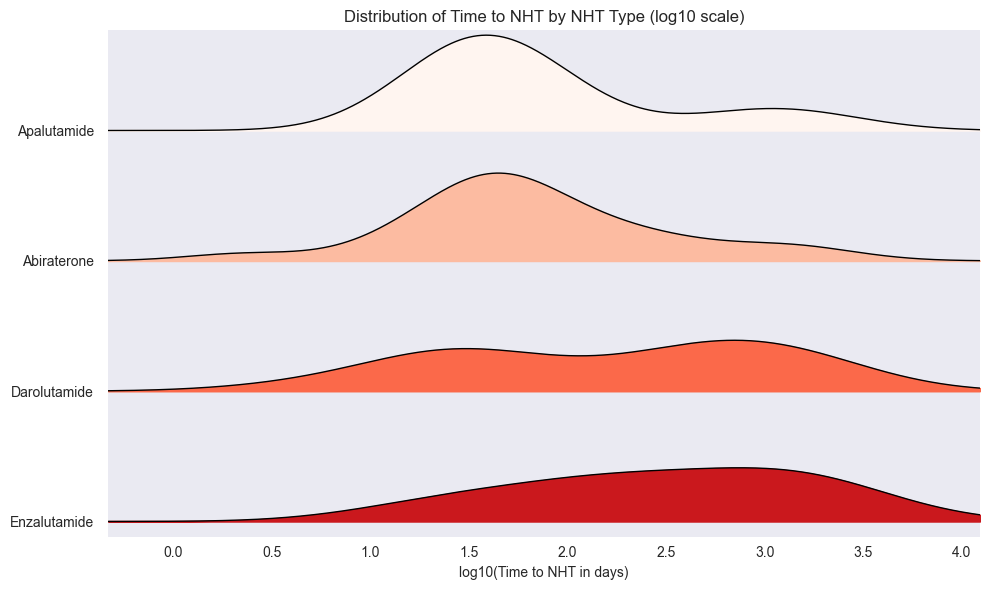

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


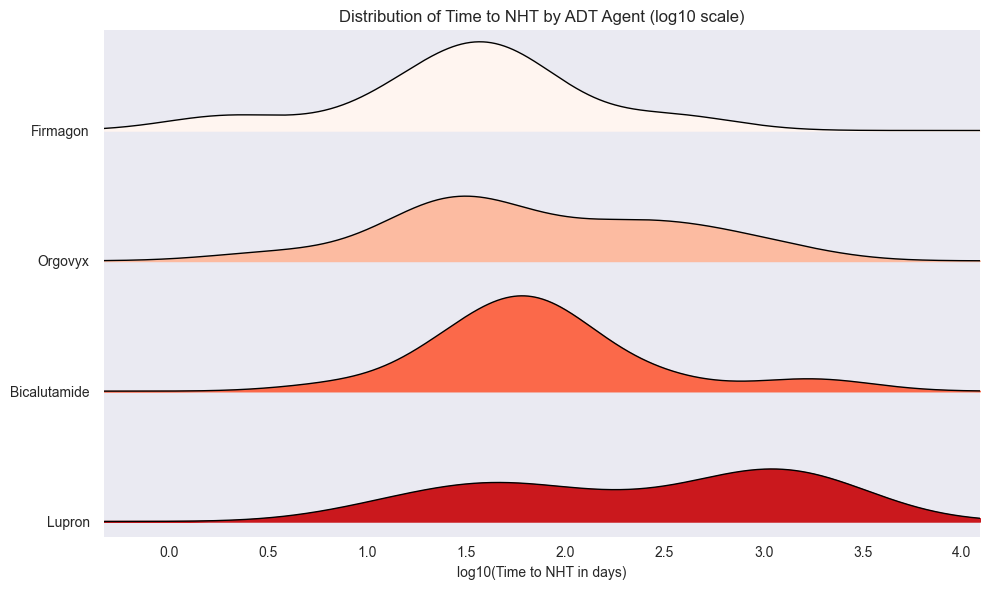

In [4]:
import joypy

def plot_ridgelines(df):
    df_plot = df[df["time_to_nht"] > 0].copy()

    # Log transform (better for skew)
    df_plot["log_time"] = np.log10(df_plot["time_to_nht"] + 1)

    # -----------------------------
    # NHT ORDERING (by median)
    # -----------------------------
    order_nht = (
        df_plot.groupby("specific_nht_used")["time_to_nht"]
        .median()
        .sort_values()
        .index
    )

    df_plot["specific_nht_used"] = pd.Categorical(
        df_plot["specific_nht_used"],
        categories=order_nht,
        ordered=True
    )

    df_plot = df_plot.sort_values("specific_nht_used")

    # -----------------------------
    # NHT RIDGELINE
    # -----------------------------
    joypy.joyplot(
        df_plot,
        by="specific_nht_used",
        column="log_time",
        overlap=1,
        figsize=(10, 6),
        colormap=plt.cm.Reds,
        linewidth=1
    )

    plt.title("Distribution of Time to NHT by NHT Type (log10 scale)")
    plt.xlabel("log10(Time to NHT in days)")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # ADT ORDERING
    # -----------------------------
    order_adt = (
        df_plot.groupby("adt_agent")["time_to_nht"]
        .median()
        .sort_values()
        .index
    )

    df_plot["adt_agent"] = pd.Categorical(
        df_plot["adt_agent"],
        categories=order_adt,
        ordered=True
    )

    df_plot = df_plot.sort_values("adt_agent")

    # -----------------------------
    # ADT RIDGELINE
    # -----------------------------
    joypy.joyplot(
        df_plot,
        by="adt_agent",
        column="log_time",
        overlap=1,
        figsize=(10, 6),
        colormap=plt.cm.Reds,
        linewidth=1
    )

    plt.title("Distribution of Time to NHT by ADT Agent (log10 scale)")
    plt.xlabel("log10(Time to NHT in days)")
    plt.tight_layout()
    plt.show()

plot_ridgelines(df_clean)


In [5]:
def kruskal_test(df, group_var):
    groups = [
        group["time_to_nht"].values
        for _, group in df.groupby(group_var)
    ]
    stat, p = stats.kruskal(*groups)
    print(f"Kruskal-Wallis ({group_var}): p = {p:.5f}")


kruskal_test(df_clean, "specific_nht_used")
kruskal_test(df_clean, "adt_agent")

def compute_pair_summary(df):
    return (
        df.groupby(["adt_agent", "specific_nht_used"])["time_to_nht"]
        .agg(["count", "median", "mean", "std"])
        .reset_index()
    )


pair_summary = compute_pair_summary(df_clean)
print(pair_summary.sort_values("median"))

Kruskal-Wallis (specific_nht_used): p = 0.54545
Kruskal-Wallis (adt_agent): p = 0.00000
       adt_agent specific_nht_used  count  median         mean          std
13       Orgovyx      Darolutamide     29    16.0   178.482759   344.236798
12       Orgovyx       Apalutamide      3    28.0    29.000000     3.605551
11       Orgovyx       Abiraterone     28    29.5    81.178571   124.176414
5       Firmagon       Apalutamide      2    36.5    36.500000    14.849242
4       Firmagon       Abiraterone     13    38.0    35.538462    22.269618
14       Orgovyx      Enzalutamide      8    52.5   257.125000   449.468396
0   Bicalutamide       Abiraterone     13    57.0   169.846154   374.149223
1   Bicalutamide       Apalutamide      3    66.0    55.666667    26.083200
7         Lupron       Abiraterone     27    69.0   396.703704   677.974859
2   Bicalutamide      Darolutamide      7    77.0   400.571429   797.155747
3   Bicalutamide      Enzalutamide      1   107.0   107.000000          NaN


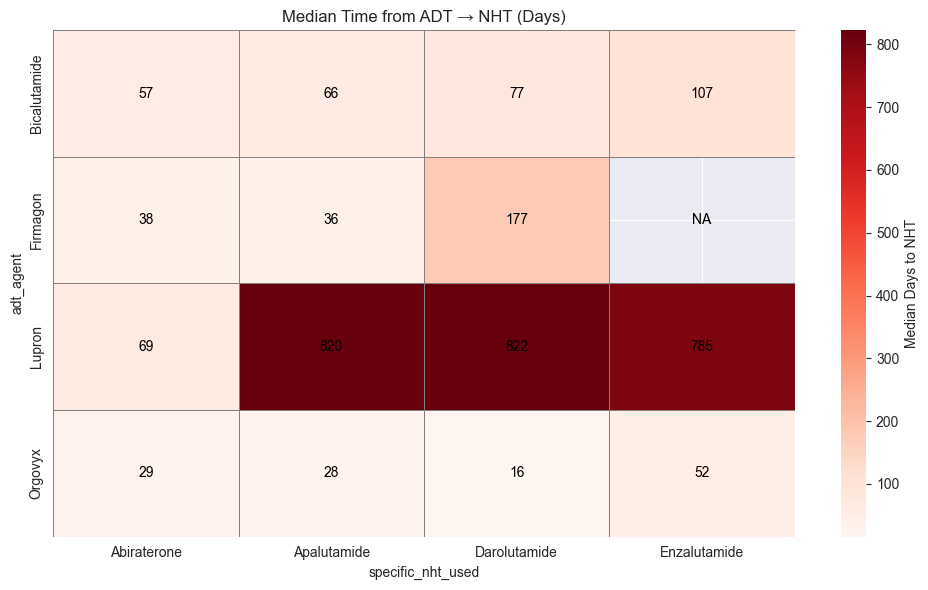

In [6]:
def plot_heatmap(pair_summary):
    heatmap_data = pair_summary.pivot(
        index = "adt_agent",
        columns = "specific_nht_used",
        values = "median"
    )

    mask = heatmap_data.isna()

    plt.figure(figsize = (10, 6))

    sns.heatmap(
        heatmap_data,
        mask = mask,
        cmap = "Reds",
        annot = False,
        linewidths = 0.5,
        linecolor = "gray",
        cbar_kws = {"label": "Median Days to NHT"}
    )

    # Manual annotations
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            val = heatmap_data.iloc[i, j]

            if pd.isna(val):
                text = "NA"
            else:
                text = f"{int(val)}"

            plt.text(j + 0.5, i + 0.5, text,
                     ha = "center", va = "center", color = "black")

    plt.title("Median Time from ADT → NHT (Days)")
    plt.tight_layout()
    plt.show()


plot_heatmap(pair_summary)

In [7]:
def filter_valid_pairs(df, pair_summary, min_n = 5):
    valid_pairs = pair_summary[pair_summary["count"] >= min_n]

    df_valid = df.merge(
        valid_pairs[["adt_agent", "specific_nht_used"]],
        on = ["adt_agent", "specific_nht_used"],
        how = "inner"
    )

    return df_valid


df_valid = filter_valid_pairs(df_clean, pair_summary)

df_valid["adt_nht_pair"] = (
        df_valid["adt_agent"] + " → " + df_valid["specific_nht_used"]
)

groups = [
    g["time_to_nht"].values
    for _, g in df_valid.groupby("adt_nht_pair")
]

stat, p = stats.kruskal(*groups)
print(f"Kruskal across ADT–NHT pairs: p = {p:.5f}")

Kruskal across ADT–NHT pairs: p = 0.00007


In [8]:
posthoc = sp.posthoc_dunn(
    df_valid,
    val_col = "time_to_nht",
    group_col = "adt_nht_pair",
    p_adjust = "bonferroni"
)

print(posthoc)

                             Bicalutamide → Abiraterone  \
Bicalutamide → Abiraterone                     1.000000   
Bicalutamide → Darolutamide                    1.000000   
Firmagon → Abiraterone                         1.000000   
Lupron → Abiraterone                           1.000000   
Lupron → Darolutamide                          0.653756   
Lupron → Enzalutamide                          1.000000   
Orgovyx → Abiraterone                          1.000000   
Orgovyx → Darolutamide                         1.000000   
Orgovyx → Enzalutamide                         1.000000   

                             Bicalutamide → Darolutamide  \
Bicalutamide → Abiraterone                      1.000000   
Bicalutamide → Darolutamide                     1.000000   
Firmagon → Abiraterone                          1.000000   
Lupron → Abiraterone                            1.000000   
Lupron → Darolutamide                           1.000000   
Lupron → Enzalutamide                           1

In [9]:
df_valid["log_time"] = np.log1p(df_valid["time_to_nht"])

model = smf.ols(
    "log_time ~ C(adt_agent) * C(specific_nht_used)",
    data = df_valid
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_time   R-squared:                       0.231
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     5.224
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.01e-05
Time:                        15:00:12   Log-Likelihood:                -317.39
No. Observations:                 148   AIC:                             652.8
Df Residuals:                     139   BIC:                             679.8
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------